# ML - Aprendizaje No Supervisado

## Clustering

De entre las diferentes técnicas de aprendizaje no supervisado, el *Clustering* es una de las más usadas. Este técnica consiste en identificar aquellas muestras similares del conjunto de datos y asignarlas a un *cluster*, o grupo. Esto permite aplicaciones tales como: segmentación de clientes, análisis de datos, reducción de la dimensionalidad, detección de anomalías, aprendizaje semi-supervisado, motores de búsqueda e incluso la semgentación de imágenes.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

Se generaron 12 clusters
Coordenadas de los centroides:
[[  1.58619052  12.21467909]
 [ 14.28364607  -2.85176372]
 [-12.89263394  13.12950955]
 [ -2.93829597   8.52057476]
 [ -7.1705114    2.09553629]
 [ -5.12377762  12.19598953]
 [ -5.33491595  -2.21487577]
 [  5.53847605  -7.73380848]
 [-12.16580271   1.10027071]
 [  9.68343463   0.72348066]
 [-10.16422177 -14.40173705]
 [ -1.32996415  -5.4935615 ]]


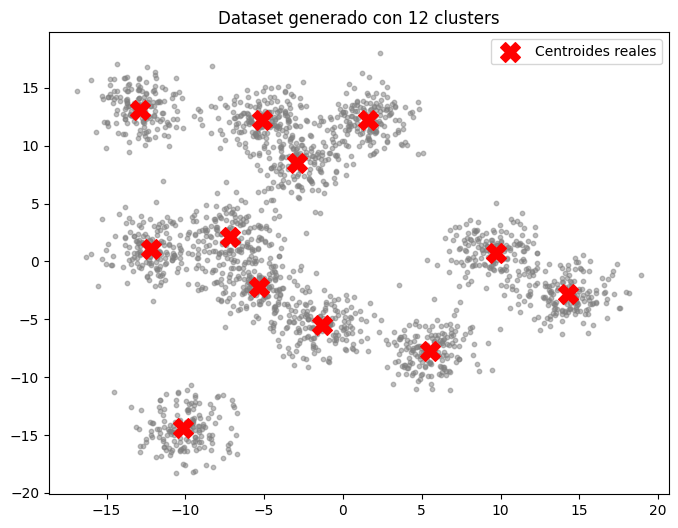

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

n_centers = random.randint(1, 20)

blob_centers = []
min_distance = 4

while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-15, 15, size=2)
    if all(np.linalg.norm(candidate - center) > min_distance for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)

blob_std = np.full(n_centers, 1.5)

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {n_centers} clusters")
print("Coordenadas de los centroides:")
print(blob_centers)

# Visualización inicial
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=10, c='gray', alpha=0.5)
plt.scatter(blob_centers[:, 0], blob_centers[:, 1], c='red', marker='X', s=200, label="Centroides reales")
plt.legend()
plt.title(f"Dataset generado con {n_centers} clusters")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

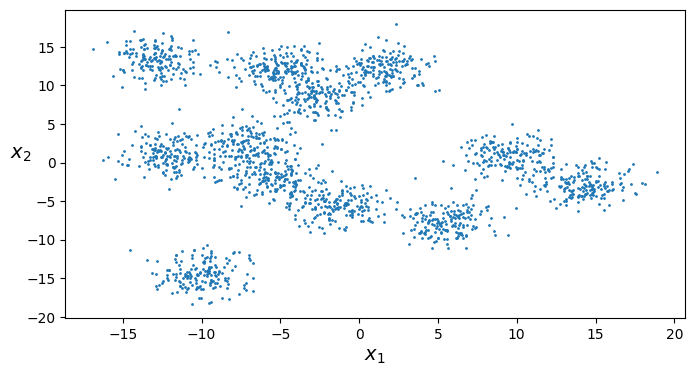

In [ ]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

k = len(blob_centers)

n_init = 10 if k <= 10 else 20

# KMeans robusto
kmeans = KMeans(n_clusters=k, random_state=42, n_init=n_init, max_iter=300)
y_pred = kmeans.fit_predict(X)

print("Primeras 30 etiquetas:", y_pred[:30])
unique, counts = np.unique(y_pred, return_counts=True)
print("Tamaños por cluster:", dict(zip(unique, counts)))
print("Inertia (suma de distancias al cuadrado):", kmeans.inertia_)

Primeras 30 etiquetas: [ 7  3  7  7  3  0  2  6 10  7  8  4  7  4  0  1  1  9 11  1  0 10  0  5
  4  5 10  5  6  2]
Tamaños por cluster: {np.int32(0): np.int64(166), np.int32(1): np.int64(169), np.int32(2): np.int64(155), np.int32(3): np.int64(168), np.int32(4): np.int64(168), np.int32(5): np.int64(172), np.int32(6): np.int64(170), np.int32(7): np.int64(169), np.int32(8): np.int64(160), np.int32(9): np.int64(164), np.int32(10): np.int64(170), np.int32(11): np.int64(169)}
Inertia (suma de distancias al cuadrado): 8394.907242593483


In [ ]:
kmeans.cluster_centers_

array([[-10.01801712, -14.47556498],
       [  5.54509249,  -7.64784333],
       [ -6.98584717,   2.5037743 ],
       [ 14.27211412,  -2.91258233],
       [-12.82112063,  13.30328032],
       [ -5.11505446,  12.39103506],
       [ -1.41072324,  -5.60627834],
       [-12.10709398,   1.01783387],
       [ -2.72882729,   8.34116924],
       [  9.49257245,   0.86494822],
       [ -5.62157393,  -2.03473201],
       [  1.57934719,  12.23602813]])

In [ ]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
pred_new = kmeans.predict(X_new)
print("Predicciones para X_new:", pred_new)

distances_new = kmeans.transform(X_new)
print("Distancias a cada centro (X_new x centros):\n", distances_new)

Predicciones para X_new: [8 9 2 2]
Distancias a cada centro (X_new x centros):
 [[19.28224334 11.12784488  7.00398809 15.09392946 17.0922579  11.5817698
   7.73599446 12.14686687  6.90339958  9.56019216  6.91962108 10.35715258]
 [20.99792873  9.9778944   9.9985465  12.29609783 19.44407375 13.18437403
   8.79260767 15.13898737  8.54575271  6.59104237  9.51896    10.33414372]
 [18.83209854 13.65266177  4.01661768 18.25608271 14.23418406  9.62626588
   8.75178996  9.32030811  5.34804857 12.67370555  5.67637    10.30895904]
 [18.36906014 13.26639853  3.98584895 18.10033076 14.60018069 10.11464433
   8.26060223  9.22691591  5.84746037 12.59911746  5.23798094 10.75921301]]


In [ ]:
def plot_data(X):
    plt.scatter(X[:, 0], X[:, 1], c='k', s=6, marker='.', alpha=0.6)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    centroids = np.asarray(centroids)
    if weights is not None:
        weights = np.asarray(weights)
        if len(weights) == len(centroids):
            mask = weights > weights.max() / 10
            centroids = centroids[mask]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=120, linewidths=1,
                facecolors=circle_color, edgecolors='k',
                zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=80, linewidths=2,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=300, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 1.0
    maxs = X.max(axis=0) + 1.0
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = clusterer.predict(grid)
    Z = Z.reshape(xx.shape)

    levels = np.arange(Z.max() + 2) - 0.5
    plt.contourf(xx, yy, Z, levels=levels, cmap="Pastel2", alpha=0.8)
    plt.contour(xx, yy, Z, levels=levels, linewidths=0.5, colors='k', alpha=0.5)

    plot_data(X)
    if show_centroids:
        centroids = clusterer.cluster_centers_
        try:
            labels = clusterer.labels_
            counts = np.bincount(labels, minlength=centroids.shape[0])
            plot_centroids(centroids, weights=counts)
        except Exception:
            plot_centroids(centroids)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=12)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=12, rotation=0)
    else:
        plt.tick_params(labelleft=False)

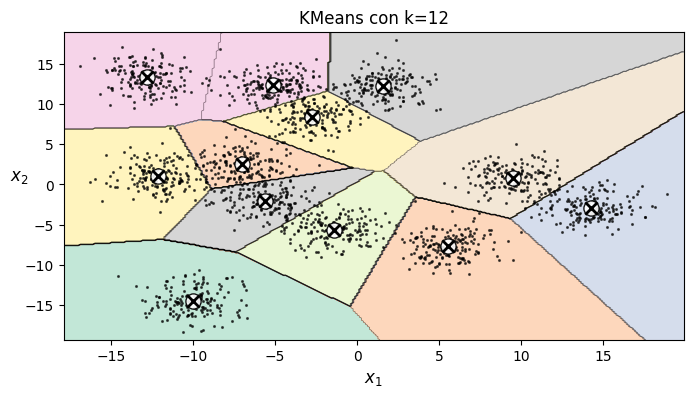

In [ ]:
plt.figure(figsize=(8, 4))
if k > 1:
    plot_decision_boundaries(kmeans, X)
else:
    plot_data(X)
    plot_centroids(kmeans.cluster_centers_)
plt.title(f"KMeans con k={k}")
plt.show()

En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [ ]:
kmeans.transform(X_new)

array([[19.28224334, 11.12784488,  7.00398809, 15.09392946, 17.0922579 ,
        11.5817698 ,  7.73599446, 12.14686687,  6.90339958,  9.56019216,
         6.91962108, 10.35715258],
       [20.99792873,  9.9778944 ,  9.9985465 , 12.29609783, 19.44407375,
        13.18437403,  8.79260767, 15.13898737,  8.54575271,  6.59104237,
         9.51896   , 10.33414372],
       [18.83209854, 13.65266177,  4.01661768, 18.25608271, 14.23418406,
         9.62626588,  8.75178996,  9.32030811,  5.34804857, 12.67370555,
         5.67637   , 10.30895904],
       [18.36906014, 13.26639853,  3.98584895, 18.10033076, 14.60018069,
        10.11464433,  8.26060223,  9.22691591,  5.84746037, 12.59911746,
         5.23798094, 10.75921301]])

Este algoritmo funciona asignando centroides de manera aleatoria y, de manera iterativa, asigna cada instancia a uno de ellos (el más cercano) tras lo cual se recalcula el centroide como el valor promedio de todas las instancias asignadas al grupo.

In [ ]:

kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1, max_iter=1, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1, max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1, max_iter=3, random_state=1)

kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

KMeans(max_iter=3, n_clusters=12, n_init=1, random_state=1)

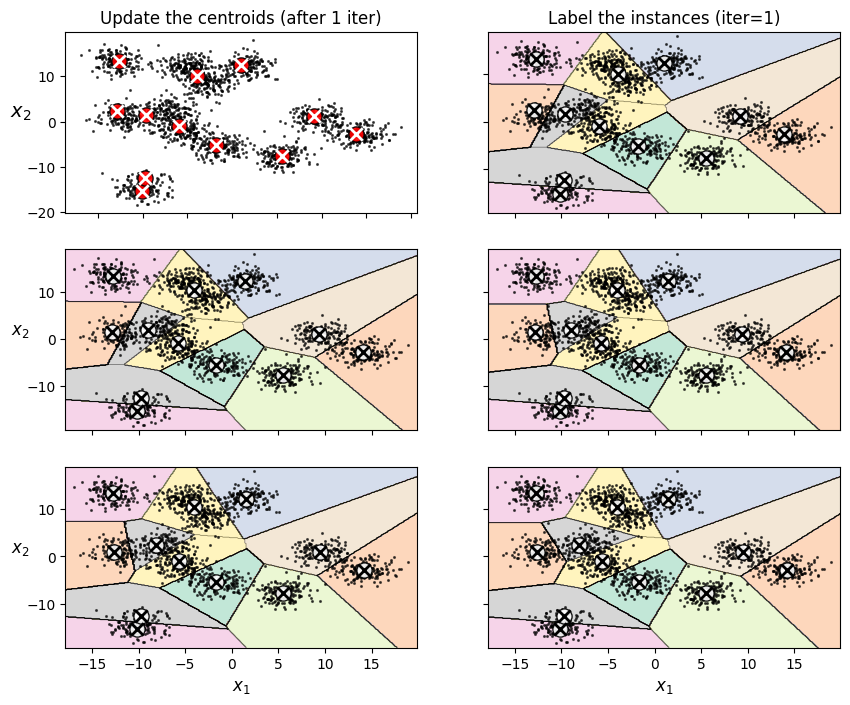

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (after 1 iter)", fontsize=12)

plt.subplot(322)
if k > 1:
    plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
else:
    plot_data(X)
plt.title("Label the instances (iter=1)", fontsize=12)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
if k > 1:
    plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)
else:
    plot_data(X)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
if k > 1:
    plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)
else:
    plot_data(X)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

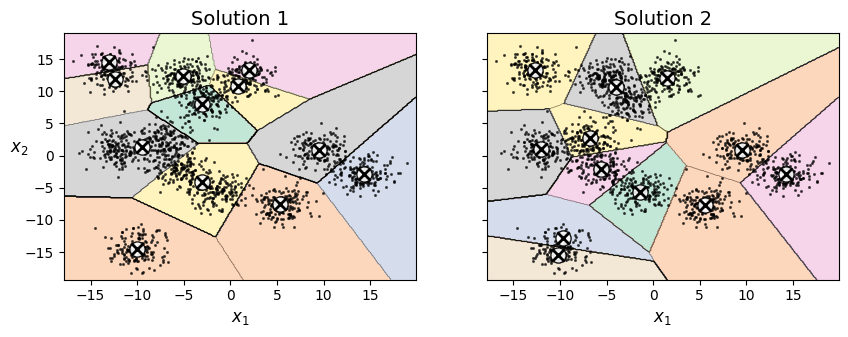

In [ ]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1, random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1, random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X, "Solution 1", "Solution 2")
plt.show()

In [ ]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10, random_state=11)
kmeans_rnd_10_inits.fit(X)

KMeans(init='random', n_clusters=12, n_init=10, random_state=11)

Para minimizar el impacto de la inicialización tenemos varias alternativas: probar varias y quedarnos con la mejor, o usar la inicialización inteligente que ofrece *Scikit-Learn* por defecto.

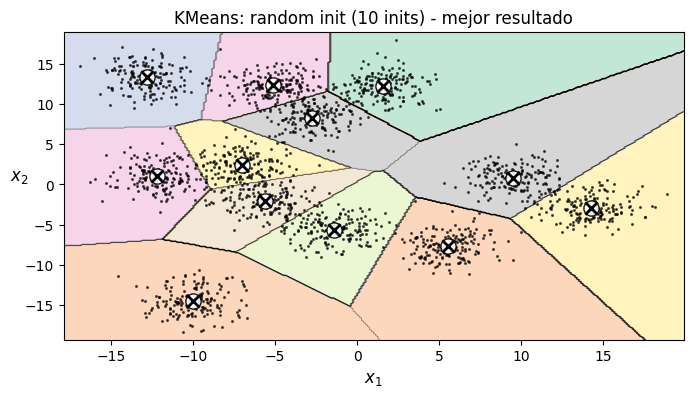

In [ ]:
plt.figure(figsize=(8, 4))
if k > 1:
    plot_decision_boundaries(kmeans_rnd_10_inits, X)
else:
    plot_data(X)
    plot_centroids(kmeans_rnd_10_inits.cluster_centers_)
plt.title("KMeans: random init (10 inits) - mejor resultado")
plt.show()

MÉTODO silhouette_score y MÉTODO DEL CODO:

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.5463597228551669)

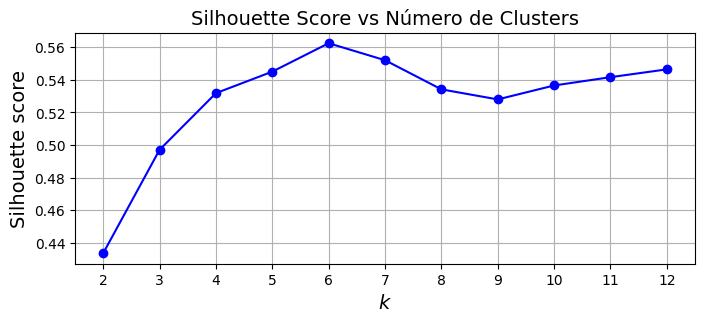

In [ ]:
max_k = min(20, len(blob_centers))

kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)
                for k in range(1, max_k + 1)]

silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.xticks(range(2, max_k + 1, 1))
plt.grid(True)
plt.show()

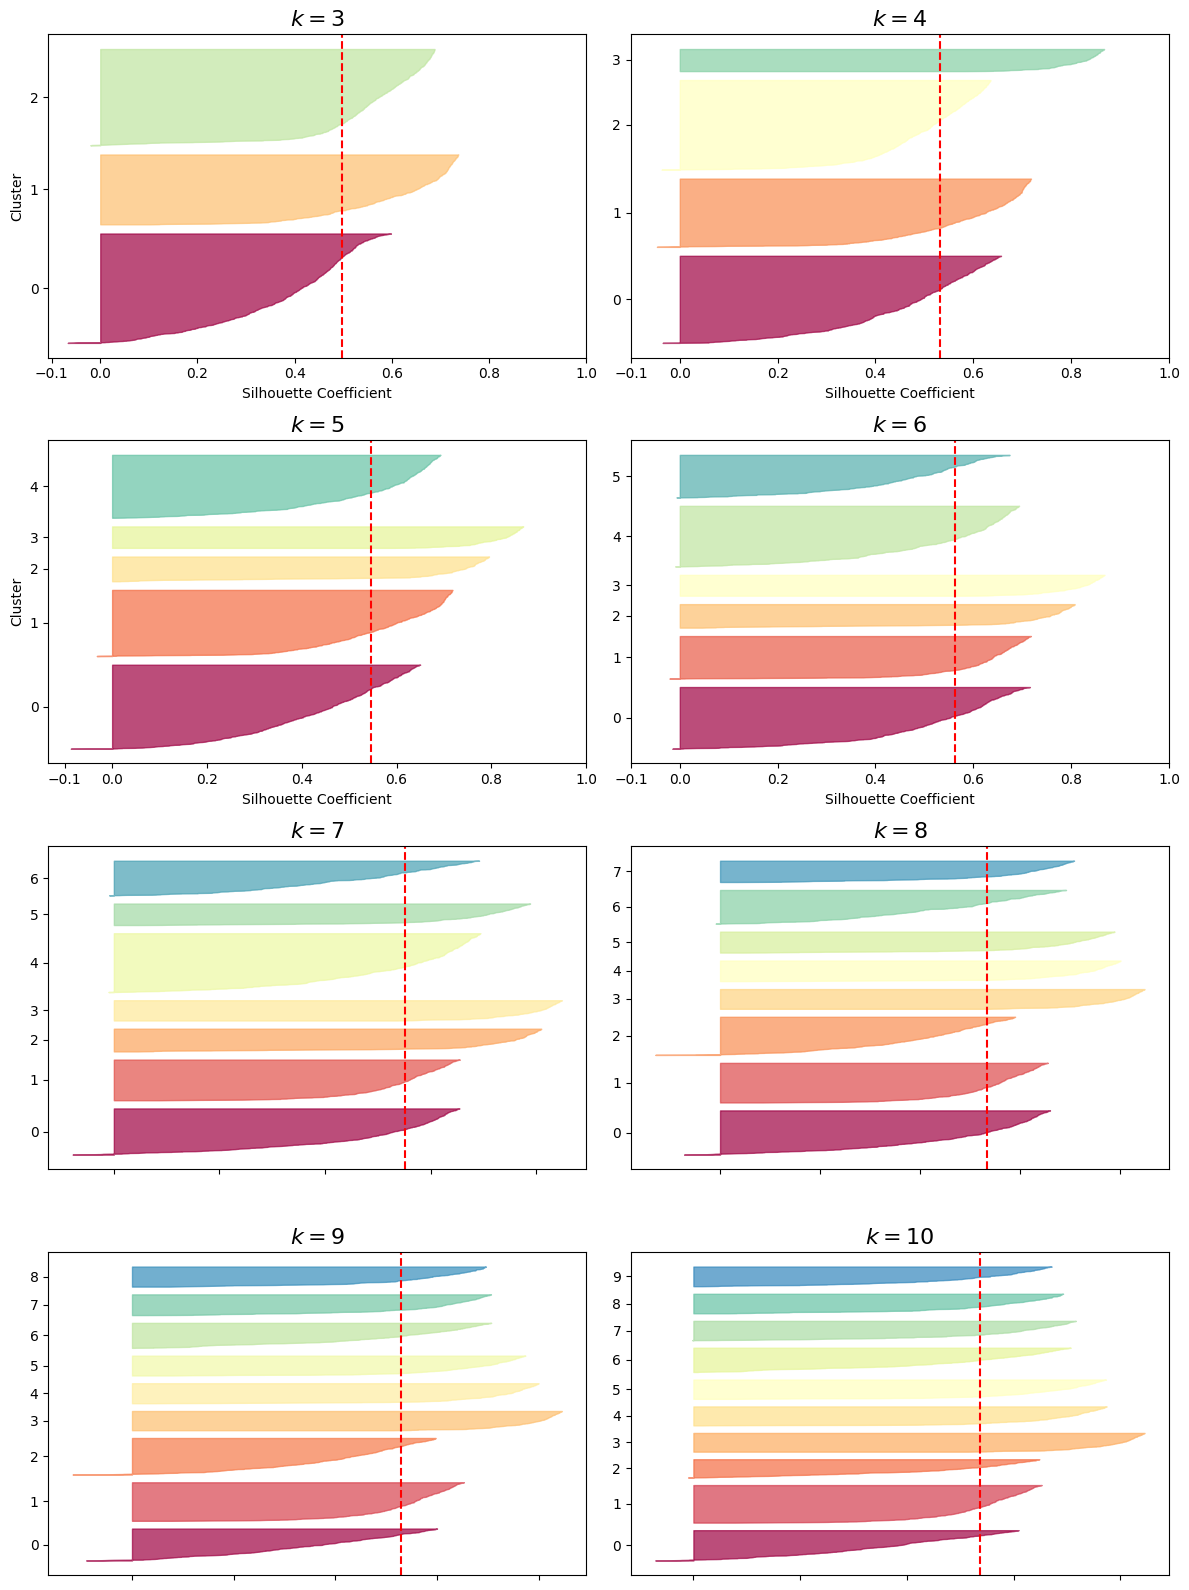

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(12, 16))

valid_ks = list(range(3, 11))

for plot_idx, k in enumerate(valid_ks):
    plt.subplot(4, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (3, 4, 5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=16)

plt.tight_layout()
plt.show()


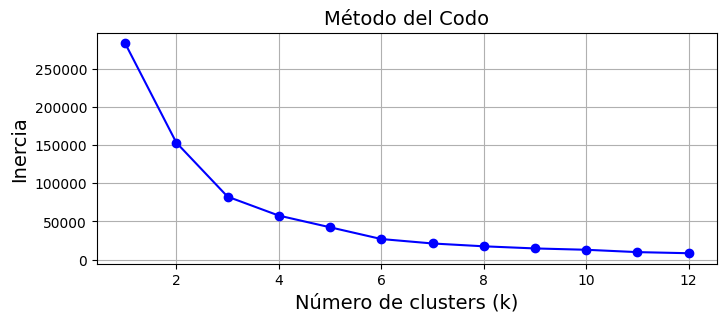

In [ ]:
# Método del Codo
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

max_k = min(20, len(blob_centers))
inertias = []

for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 3))
plt.plot(range(1, max_k + 1), inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del Codo", fontsize=14)
plt.grid(True)
plt.show()